# Кейс "Лидскоринг - поиск потенциальных клиентов"
---

> **В общем виде задача лидскоринга звучит так: <font color="green">нужно найти контрагентов, которые заинтересованы в услугах бизнеса</font>.**

<br>

**Традиционный подход: как обычно решают задачу лидскоринга** <br>
**Методика выбора клиентов для обзвона:**

- тотальный обзвон **всех клиентов** из базы
- отбор клиентов для обзвона **по базовым фильтрам** (на основе здравого смысла) по небольшому числу признаков (например, вид деятельности - "грузоперевозки")
- отбор клиентов для обзвона **по простым правилам** (например, выручка за год > 1 млн. рублей и вид деятельности - "грузоперевозки")

**Недостатки подхода:**

- устанавливаемые простые фильтры ограничены и не учитывают множество важных факторов (например, выбранная по базовым фильтрам компания может находиться далеко от АЗС ГПН)
- на обзвон и поиск тратится очень много времени
- появляются упущенные возможности привлечения действительно целевых контрагентов

В связи с этим возникает **необходимость разработки более интеллектуального подхода** к выбору клиентов для обзвона:

> **В результате решения задачи с использованием интеллектуального подхода хотим получить <font color="green">список клиентов, которые с большой вероятностью заинтересуются нашими услугами</font> и осуществлять обзвон в превую очередь по ним.**

<br>

**Новый подход: лидскоринг с использованием машинного обучения**

Новый подход заключается в том, чтобы отбирать клиентов **не по наборам простых фильтров и условий, а на основе более сложных закономерностей**. <br>
Классом методов, позволяющих выявлять сложные закономерности в данных является - класс задач машинного обучения (**Machine Learning**). Именно машинное обучение легло в основу реализации данного проекта.

> **Машинное обучение позволяет выявить в данных <font color="green">неинтуитивные закономерности.</font>**

<br>

Когда мы говорим о задаче машинного обучения, предполагается, что решать мы ее будем **на основе имеющихся данных**.<br>

> **Все модели машинного обучения строятся <font color="green">на основе данных!</font>**

<br>

Данные обычно представляются **в табличном виде**, где каждая **строка** таблицы - это отдельное наблюдение - объекты, которые мы хотим рассматривать (контрагенты), а **столбцы** - это характеристики контрагента (например, его финансовые показатели, вид деятельности, налоговый режим и прочее).

Пример:

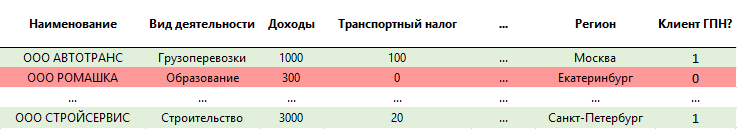

Чтобы начать работу с данными, нужно ответить на следующие вопросы:

Про **строчки** таблицы:

> **<font color="blue">Каких контрагентов нужно взять для анализа?</font> Нужно брать всех? А тех, что не наши брать нужно?**

<br>

> **Каждая строчка таблицы представляет отдельное <font color="green">наблюдение</font>, а весь набор строк представляет собой <font color="green">выборку</font> из <font color="green">генеральной совокупности.</font>**

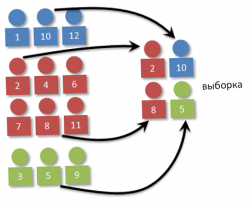

<br>

Про **столбцы** таблицы:

> **<font color="blue">Что именно будем моделировать?</font> Какую величину? Как ее сформулировать? А если точнее?**

<br>

> **То, что мы хотим научиться моделировать называется <font color="green">результатом, откликом </font> или <font color="green">результирующей переменной</font>.**

<br>

> **<font color="blue">Какие факторы должны на это влиять?</font> Какие данные нам понадобятся?**

<br>

> **Характеристики или факторы также называются <font color="green">фичами, признаками</font> или <font color="green">независимыми переменными</font>.**

<br>

## Описание данных

Для решения поставленной задачи (реальной, не учебной) используется 2 источника данных:
- набор данных о контрагентах из системы **СПАРК-Интерфакс** <br>
  Система **СПАРК-Интерфакс** содержит общую и финансовую информацию о всех юридических лицах 
- информация об автопарке из системы **АВТОСТАТ** <br>
  Система **АВТОСТАТ** - это онлайн система анализа автомобильных региональных данных, позволяющая работать с огромными массивами данных по регистрациям и парку по всем типам транспортных средств во всех регионах России. 

В качестве **выборки** мы сгенерировали случайным образом набор контрагентов и данные по ним.

В качестве **результирующей переменной** мы выбрали **факт** того, что контрагента заинтересуют наши услуги или **вероятность** того, что контрагента заинтересуют наши услуги. Но об этом пы поговорим чуть позже.

> **Начальный набор факторов определяет аналитическая команда. <font color="green">Здесь важную роль играет аналитик, который понимает как устроен бизнес и понимает как будет работать модель.</font>**

<br>

# install

**Python** - как книжная полка с книгами-инструкциями по работе с данными. <br>
Инструкции представляют собой набор готовых алгоритмов, которые мы можем использовать (здесь нам не нужно изобретать велосипед и писать алгоритмы самим). Чтобы применить алгоритмы правильно, нам нужно "взять с полки" нужную инструкцию (на языке питона они назывываются пакетами).

In [1]:
# pip install matplotlib==3.7.5 -q
# pip install numpy==1.26.4 -q
# pip install pandas==2.0.3 -q
# pip install seaborn==0.13.2 -q
# pip install pydantic==2.3.0 -q
# pip install typing_extensions==4.7.1 -q
# pip install scikit-learn==1.3.2 -q

# imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import pydantic
from pydantic import BaseModel, field_validator
from typing import List
from typing import Optional

from sklearn.preprocessing import StandardScaler

# Раздел 1. Обработка входных данных и датасета

## Исходные данные

Данные о контрагентах-наших клиентах и о контрагентах-потенциальных клиентах были выгружены из систем-источников и сохранены в отдельные файлы. Теперь нам нужно загрузить эти данные для работы с ними.

Расшифровка переменных:

| Переменные | Описание | Дополнительно |
| --- | --- | --- |
| ClientId | Id компании/клиента|  |
| Target | Наш клиент/Не наш клиент | 0 = Не наш, 1 = Наш |
| Size | Размер компании | 1 = Крупные, 2 = Средние, 3 = Малые |
| Company | Наименование компании |  |
| Org | Организационно-правовая форма | 1 = ООО, 2 = АО |
| Age | Возраст компании в годах |  |
| Truck | Количество грузовых автомобилей в собственности|  |
| Car | Количество легковых автомобилей в собственности|  |
| TypeActivity | Вид деятельности |  |
| Assets | Активы 2025|  |
| Department | Основной регион деятельности |  |
| Risk | Индикатор риска | 1 = Низкий риск, 2 = Средний риск, 3 = Высокий риск |

**Прогнозируемая переменная** - Target. Остальные столбцы - **признаки**.

In [3]:
df = pd.read_csv('data/train.csv', encoding = 'cp1251')

In [4]:
df

,ClientId,Target,Risk,Company,Org,Age,Truck,Car,TypeActivity,Assets,Department,Size
0,1,0,3,МСГРУПП,Акционерные общества,22.0,1,0,Строительство жилых и нежилых зданий,7.2500,Новгородская область,Малые предприятия
1,2,1,1,ХИМПРОМ,Общества с ограниченной ответственностью,38.0,1,0,Торговля оптовая неспециализированная,71.2833,Чувашская Республика-Чувашия,Средние предприятия
2,3,1,3,АСМОТО ТАГИЛ,Общества с ограниченной ответственностью,26.0,0,0,Торговля розничная легковыми автомобилями и ле...,7.9250,Москва,Малые предприятия
3,4,1,1,КЕРАМЗИТ-НТ,Общества с ограниченной ответственностью,35.0,1,0,Торговля оптовая прочими строительными материа...,53.1000,Свердловская область,Малые предприятия
4,5,0,3,СМ ТРАНС,Акционерные общества,35.0,0,0,Деятельность автомобильного грузового транспор...,8.0500,Москва,Малые предприятия
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,ФИНАГРО ЛОГИСТИК,Акционерные общества,27.0,0,0,"Торговля оптовая зерном, необработанным табако...",13.0000,Свердловская область,Малые предприятия
887,888,1,1,РЕФТЕРМОТРАНС,Общества с ограниченной ответственностью,19.0,0,0,Деятельность автомобильного грузового транспорта,30.0000,Новосибирская область,Малые предприятия
888,889,0,3,РБК-ЛОГИСТИК,Общества с ограниченной ответственностью,NaN,1,2,Деятельность автомобильного грузового транспор...,23.4500,Тюменская область,Малые предприятия
889,890,1,1,МЯСНОЙ ДВОР УРАЛ,Акционерные общества,26.0,0,0,Торговля оптовая мясом и мясными продуктами,30.0000,Ярославская область,Средние предприятия


Выведем первые 5 строк:

In [5]:
df.head()

,ClientId,Target,Risk,Company,Org,Age,Truck,Car,TypeActivity,Assets,Department,Size
0,1,0,3,МСГРУПП,Акционерные общества,22.0,1,0,Строительство жилых и нежилых зданий,7.2500,Новгородская область,Малые предприятия
1,2,1,1,ХИМПРОМ,Общества с ограниченной ответственностью,38.0,1,0,Торговля оптовая неспециализированная,71.2833,Чувашская Республика-Чувашия,Средние предприятия
2,3,1,3,АСМОТО ТАГИЛ,Общества с ограниченной ответственностью,26.0,0,0,Торговля розничная легковыми автомобилями и ле...,7.9250,Москва,Малые предприятия
3,4,1,1,КЕРАМЗИТ-НТ,Общества с ограниченной ответственностью,35.0,1,0,Торговля оптовая прочими строительными материа...,53.1000,Свердловская область,Малые предприятия
4,5,0,3,СМ ТРАНС,Акционерные общества,35.0,0,0,Деятельность автомобильного грузового транспор...,8.0500,Москва,Малые предприятия


Выведем последние 5 строк:

In [6]:
df.tail()

,ClientId,Target,Risk,Company,Org,Age,Truck,Car,TypeActivity,Assets,Department,Size
886,887,0,2,ФИНАГРО ЛОГИСТИК,Акционерные общества,27.0,0,0,"Торговля оптовая зерном, необработанным табако...",13.00,Свердловская область,Малые предприятия
887,888,1,1,РЕФТЕРМОТРАНС,Общества с ограниченной ответственностью,19.0,0,0,Деятельность автомобильного грузового транспорта,30.00,Новосибирская область,Малые предприятия
888,889,0,3,РБК-ЛОГИСТИК,Общества с ограниченной ответственностью,NaN,1,2,Деятельность автомобильного грузового транспор...,23.45,Тюменская область,Малые предприятия
889,890,1,1,МЯСНОЙ ДВОР УРАЛ,Акционерные общества,26.0,0,0,Торговля оптовая мясом и мясными продуктами,30.00,Ярославская область,Средние предприятия
890,891,0,3,УРАЛТРАНССЕРВИС,Акционерные общества,32.0,0,0,"Деятельность вспомогательная прочая, связанная...",7.75,Свердловская область,Крупные предприятия


> В данных есть пропуски, как минимум по столбцу Age

<div class='alert alert-block alert-success'>Посмотрите, что выводит метод sample(5)</div>

Выведем размер dataframe'a:

In [7]:
df.shape

(891, 12)

> Наблюдений 891, фичей 12

Выведем перечень столбцов:

In [8]:
df.columns

Index(['ClientId', 'Target', 'Risk', 'Company', 'Org', 'Age', 'Truck', 'Car',
       'TypeActivity', 'Assets', 'Department', 'Size'],
      dtype='object')

Выведем инфо о столбцах: кол-во ненулевых значений и тип данных:

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ClientId      891 non-null    int64  
 1   Target        891 non-null    int64  
 2   Risk          891 non-null    int64  
 3   Company       891 non-null    object 
 4   Org           891 non-null    object 
 5   Age           714 non-null    float64
 6   Truck         891 non-null    int64  
 7   Car           891 non-null    int64  
 8   TypeActivity  891 non-null    object 
 9   Assets        891 non-null    float64
 10  Department    332 non-null    object 
 11  Size          889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Выведем число пропусков по столбцам:

In [10]:
df.isna().sum()

ClientId          0
Target            0
Risk              0
Company           0
Org               0
Age             177
Truck             0
Car               0
TypeActivity      0
Assets            0
Department      559
Size              2
dtype: int64

> Есть пропуски по столбцам Age, Department, Size

<div class='alert alert-block alert-success'>Попробуйте вывести обратное - число заполненных строк по столбцам с помощью метода notna()</div>

Выведем типы данных по столбцам:

In [11]:
df.dtypes

ClientId          int64
Target            int64
Risk              int64
Company          object
Org              object
Age             float64
Truck             int64
Car               int64
TypeActivity     object
Assets          float64
Department       object
Size             object
dtype: object

> Object столбцы: Company, Org, TypeActivity, Department, Size

> Numeric (int/float) столбцы: остальные

<div class='alert alert-block alert-success'>Попробуйте вывести тип данных колонки с помощью метода dtype</div>

Число дублирующих строк:

In [12]:
df.duplicated().sum()

0

> Дублирующих строк нет

Число уникальных значений по каждому столбцу:

In [13]:
df.nunique()

ClientId        891
Target            2
Risk              3
Company         880
Org               2
Age              88
Truck             7
Car               7
TypeActivity    286
Assets          250
Department       32
Size              3
dtype: int64

> ClientId уникально и соответствует числу строк

ClientId не несет доп информации, можно задать как индекс

In [14]:
df['ClientId'].nunique() == df.shape[0]

True

In [15]:
df = df.set_index('ClientId')

In [16]:
cols_less_10_values = []
for column in df.columns:
    n_values = df[f'{column}'].nunique()
    if n_values < 10:
        cols_less_10_values.append(column)

Записали столбцы с кол-вом значений меньше 10 в список, выведем все значения по этим столбцам (исключив nan'ы).

In [17]:
for col in cols_less_10_values:
    print(f'Unique values in {col}:\n', df[col].dropna().unique())

Unique values in Target:
 [0 1]
Unique values in Risk:
 [3 1 2]
Unique values in Org:
 ['Акционерные общества' 'Общества с ограниченной ответственностью']
Unique values in Truck:
 [1 0 3 4 2 5 8]
Unique values in Car:
 [0 1 2 5 3 4 6]
Unique values in Size:
 ['Малые предприятия' 'Средние предприятия' 'Крупные предприятия']


> Object столбцы с небольшим числом значений можно перекодировать (Org, Size, Risk)

<div class='alert alert-block alert-success'>Попробуйте вывести число уникальных значений для колонки Size с помощью метода unique() без исключения nan'ов методом dropna()</div>

Описательные статистики для числовых столбцов:

In [18]:
df.describe().round(2)

,Target,Risk,Age,Truck,Car,Assets
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,514.13


Описательные статистики для категориальных столбцов:

In [19]:
df.describe(include='object')

,Company,Org,TypeActivity,Department,Size
count,891,891,891,332,889
unique,880,2,286,32,3
top,СИМА-ЛЕНД,Акционерные общества,Строительство жилых и нежилых зданий,Новосибирская область,Малые предприятия
freq,2,577,70,51,644


> В выборке преобладают АО, большинство команий - маленькие предприятия.

<div class='alert alert-block alert-success'>Попробуйте для метода describe() задать значение параметра include='all'</div>

Распределение таргета:

In [20]:
df['Target'].value_counts(normalize=True)

Target
0    0.616162
1    0.383838
Name: proportion, dtype: float64

> Выборка несбалансированная, можно учесть это при построении модели

<div class='alert alert-block alert-success'>Попробуйте для метода value_counts() задать значение параметра normalize=False</div>

## Валидация таблицы

In [21]:
df.nunique()

Target            2
Risk              3
Company         880
Org               2
Age              88
Truck             7
Car               7
TypeActivity    286
Assets          250
Department       32
Size              3
dtype: int64

In [22]:
class ClientRecord(BaseModel):
    Target: int
    Risk: int
    Company: str
    Org: str
    Age: Optional[float] # can be null
    Truck: int = 0 # default value
    Car: int = 0 # default value
    TypeActivity: str
    Assets: float
    Department: Optional[str] # can be null
    Size: Optional[str] # can be null
    
    @field_validator('Target')
    def target_must_be_zero_or_one(cls, v):
        if v not in [0, 1]:
            raise ValueError('target_must_be_zero_or_one')
        return v
    # по аналогии можно проверить значения Risk
    @field_validator('Size')
    def size_must_be_fixed(cls, v):
        if v not in ['Малые предприятия', 'Средние предприятия', 'Крупные предприятия']: # add None
            raise ValueError('size_must_be_fixed')
        return v
    # по аналогии можно проверить значения Org
    @field_validator('Assets')
    def assets_must_be_positive_or_zero(cls, v):
        if v < 0:
            raise ValueError('assets_must_be_positive_or_zero')
        return v

In [23]:
df.isnull().sum()

Target            0
Risk              0
Company           0
Org               0
Age             177
Truck             0
Car               0
TypeActivity      0
Assets            0
Department      559
Size              2
dtype: int64

In [24]:
rows = df.replace(np.nan, None).replace(float('nan'), None).to_dict(orient='records')

In [25]:
# rows = df.to_dict(orient='records')

In [26]:
def validate_clients_data(data: List[dict]):
    valid_records = []
    invalid_records = []
    
    for row in rows:
        try:
            valid_record = ClientRecord(**row)
            valid_records.append(valid_record)
        except ValueError as e:
            invalid_records.append((row, str(e)))
    
    return valid_records, invalid_records

In [27]:
valid_records, invalid_records = validate_clients_data(rows)

In [28]:
len(valid_records)

889

In [29]:
len(invalid_records)

2

Для двух строк значение Size не входит в диапазон значений - это пропуски. Можно скорректировать схему валидации, чтобы она допускала пропуски в значениях.

In [30]:
invalid_records

[({'Target': 1,
   'Risk': 1,
   'Company': 'ТЕХТРЕЙД',
   'Org': 'Общества с ограниченной ответственностью',
   'Age': 38.0,
   'Truck': 0,
   'Car': 0,
   'TypeActivity': 'Торговля оптовая прочими потребительскими товарами, не включенными в другие группировки',
   'Assets': 80.0,
   'Department': 'Санкт-Петербург',
   'Size': None},
  '1 validation error for ClientRecord\nSize\n  Value error, size_must_be_fixed [type=value_error, input_value=None, input_type=NoneType]\n    For further information visit https://errors.pydantic.dev/2.3/v/value_error'),
 ({'Target': 1,
   'Risk': 1,
   'Company': 'ТЕХБЕТОН',
   'Org': 'Общества с ограниченной ответственностью',
   'Age': 62.0,
   'Truck': 0,
   'Car': 0,
   'TypeActivity': 'Торговля оптовая лесоматериалами, строительными материалами и санитарно-техническим оборудованием',
   'Assets': 80.0,
   'Department': 'Свердловская область',
   'Size': None},
  '1 validation error for ClientRecord\nSize\n  Value error, size_must_be_fixed [type=val

In [31]:
class ClientRecord(BaseModel):
    # ClientId: int
    Target: int
    Risk: int
    Company: str
    Org: str
    Age: Optional[float] # can be null
    Truck: int = 0 # default value
    Car: int = 0 # default value
    TypeActivity: str
    Assets: float
    Department: Optional[str] # can be null
    Size: Optional[str] # can be null
    
    @field_validator('Target')
    def target_must_be_zero_or_one(cls, v):
        if v not in [0, 1]:
            raise ValueError('target_must_be_zero_or_one')
        return v
    # по аналогии можно проверить значения Risk
    @field_validator('Size')
    def size_must_be_fixed(cls, v):
        if v not in ['Малые предприятия', 'Средние предприятия', 'Крупные предприятия', None]: # add None
            raise ValueError('size_must_be_fixed')
        return v
    # по аналогии можно проверить значения Org
    @field_validator('Assets')
    def assets_must_be_positive_or_zero(cls, v):
        if v < 0:
            raise ValueError('assets_must_be_positive_or_zero')
        return v

In [32]:
valid_records, invalid_records = validate_clients_data(rows)

In [33]:
len(invalid_records)

0

<div class='alert alert-block alert-success'>Попробуйте для проверки assets_must_be_positive_or_zero задать ограничение только на положительно значение (исключить ноль)</div>

## Поиск выбросов IQR

Найти выбросы в наборе данных можно с помощью межквартильного диапазона. Межквартильный диапазон (сокращенно IQR) представляет собой разницу между 25-м процентилем (Q1) и 75-м процентилем (Q3) в наборе данных. Он измеряет разброс средних 50% значений. Можно объявить наблюдение выбросом, если его значение в 1,5 раза больше или меньше, чем границы верхняя или нижняя IQR.

### Age

In [34]:
# исключаем пропуски перед расчетом
q75, q25 = np.percentile(df['Age'].dropna(), [75, 25])
intr_qr = q75 - q25
 
max_val = q75 + (1.5 * intr_qr)
min_val = q25 - (1.5 * intr_qr)
outlier_age = []
count_age = 0
for age in df['Age']:
    if age < min_val or age > max_val:
        outlier_age.append(age)
        count_age += 1
if len(outlier_age) == 0:
    print('No of outliers in Age column:',count)
else:
    print(f'{len(outlier_age)} outliers found in Age column')

11 outliers found in Age column


In [35]:
sorted(outlier_age)

[65.0, 65.0, 65.0, 66.0, 70.0, 70.0, 70.5, 71.0, 71.0, 74.0, 80.0]

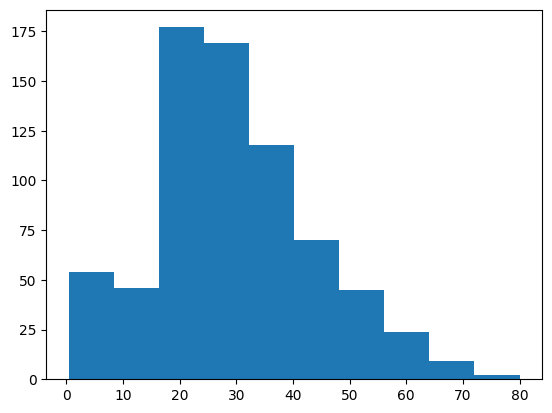

In [36]:
plt.hist(df['Age']);

<div class='alert alert-block alert-success'>Попробуйте задать значение числа бинов через параметр bins=20 в функции hist()</div>

<Axes: xlabel='Age'>

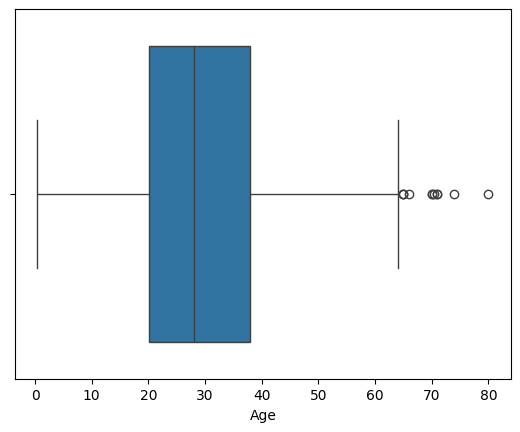

In [37]:
sns.boxplot(x='Age', data=df)

> Не похоже на выбросы, не будем удалять выбросы по методу IQR

### Assets

In [38]:
q75, q25 = np.percentile(df['Assets'].dropna(), [75, 25])
intr_qr = q75 - q25
 
max_val = q75 + (1.5 * intr_qr)
min_val = q25 - (1.5 * intr_qr)
outlier_asset = []
count_asset = 0
for asset in df['Assets'].dropna():
    if asset < min_val or asset > max_val:
        outlier_asset.append(asset)
        count_asset += 1
if len(outlier_asset) == 0:
    print('No of outliers in Assets column:',count)
else:
    print(f'{len(outlier_asset)} outliers found in Assets column')

116 outliers found in Assets column


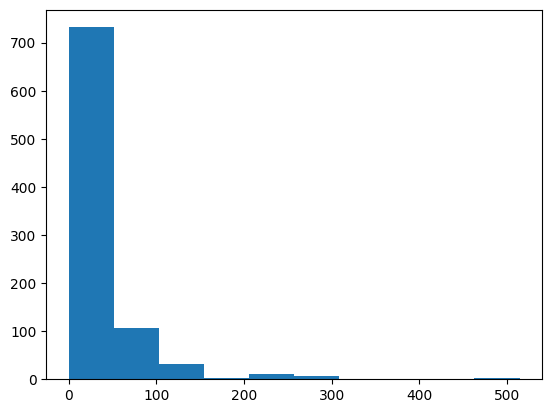

In [39]:
plt.hist(df['Assets']);

Посмотрим на правый хвост с суммой около 500:

In [40]:
df[df['Assets']>=400]

,Target,Risk,Company,Org,Age,Truck,Car,TypeActivity,Assets,Department,Size
ClientId,,,,,,,,,,,
259,1,1,ЭССМО,Общества с ограниченной ответственностью,35.0,0,0,"Торговля оптовая моторным топливом, включая ав...",510.4673,NaN,Средние предприятия
680,1,1,БЕРЕЗОВСКИЙ ПРОДСНАБ,Акционерные общества,36.0,0,1,Торговля оптовая неспециализированная пищевыми...,514.1327,NaN,Средние предприятия
738,1,1,КОМПАНИЯ ДИАГНОСТИКА,Акционерные общества,35.0,0,0,"Торговля оптовая изделиями, применяемыми в мед...",512.3292,Новосибирская область,Средние предприятия


Активы клиентов аномально высокие, но при этом компании похожи, не будем считать выбросами по смыслу (хотя числовые значения похожи на выбросы).

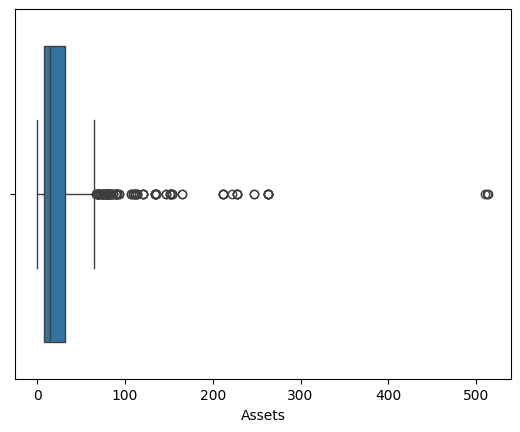

In [41]:
sns.boxplot(x='Assets', data=df);

## Обработка пропусков

Число пропусков по столбцам:

In [42]:
df.isna().sum()

Target            0
Risk              0
Company           0
Org               0
Age             177
Truck             0
Car               0
TypeActivity      0
Assets            0
Department      559
Size              2
dtype: int64

Процент пропусков по столбцам

In [43]:
df.isna().sum() * 100 / len(df)

Target           0.000000
Risk             0.000000
Company          0.000000
Org              0.000000
Age             19.865320
Truck            0.000000
Car              0.000000
TypeActivity     0.000000
Assets           0.000000
Department      62.738496
Size             0.224467
dtype: float64

Визуализация пропусков по столбцам в виде heatmap:

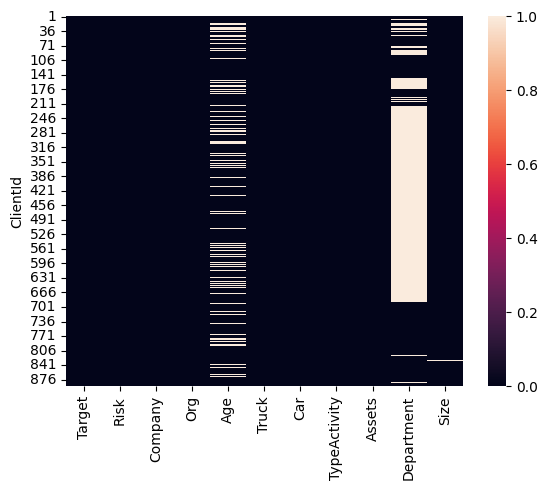

In [44]:
sns.heatmap(df.isna());

> Пропущенные значения содержатся по трем столбцам - Age, Departmet, Size. Число пропусков по столбцу Departmet большое, удалить этот столбец. Остальные пропуски можно заполнить.

**Подходы к заполнению пропусков**:
1. Для числовых переменных - Заполнение отдельным экстремальным числом, например -999 для столбца с положительными значениями
2. Для категориальных переменных - Новая категория для пропусков
3. Удаление строк с пропусками
4. Заполнение средним, медианой, модой
5. Заполнение средним, медианой, модой по группе
6. Заполнение следующим или предыдущим значением
7. Для числовых переменных - Заполнение с помощью ML моделей, например, knn или регрессией

### Department

Столбец Department удаляем, т.к. число пропусков большое:

In [45]:
df = df.drop('Department', axis=1)

In [46]:
df.shape

(891, 10)

> Уменьшили число признаков

### Age

Пропуски по Age заполним средним (mean) Age в группировке по Risk, Org:

In [47]:
mean_age_risk_org = df.groupby(['Risk', 'Org'])['Age'].mean()

In [48]:
mean_age_risk_org

Risk  Org                                     
1     Акционерные общества                        41.281386
      Общества с ограниченной ответственностью    34.611765
2     Акционерные общества                        30.740707
      Общества с ограниченной ответственностью    28.722973
3     Акционерные общества                        26.507589
      Общества с ограниченной ответственностью    21.750000
Name: Age, dtype: float64

In [49]:
for risk in df['Risk'].unique():
    for org in df['Org'].unique():
        df.loc[(df['Risk']==risk) & (df['Org']==org) & (df['Age'].isna()), 'Age'] = df.loc[(df['Risk']==risk) & (df['Org']==org) & (df['Age'].isna()), 'Age'].fillna(mean_age_risk_org[risk, org])

> Пропуски по Age заполнили средним по Risk, Org

<div class='alert alert-block alert-success'>Попробуйте заполнить пропуски Age более простым методом, например, медианой df['Age'].median()</div>

### Size

Небольшое кол-во пропусков Size можно заполнить самым частым значением (mode = most frequent):

In [50]:
df['Size'].value_counts()

Size
Малые предприятия      644
Средние предприятия    168
Крупные предприятия     77
Name: count, dtype: int64

In [51]:
df['Size'].value_counts(dropna=False)

Size
Малые предприятия      644
Средние предприятия    168
Крупные предприятия     77
NaN                      2
Name: count, dtype: int64

In [52]:
df['Size'] = df['Size'].fillna(df['Size'].mode().item())

> Пропуски по Size заполнили модой

<div class='alert alert-block alert-success'>Попробуйте заполнить пропуски Size отдельным значением, например, 'NA'</div>

In [53]:
df.isna().sum().sum()

0

> Больше пропусков нет

**Итого по разделу 1**
* дубликатов по строкам нет
* по методу IQR выбросы по Age, Assets не были удалены
* пропуски по столбцам были заполнены для числовых столбцов (Age) - средним (с учетом группировки), для категориальных столбцов (Size) - модой
* столбцы с большим числом пропусков (Department) были удалены

# Раздел 2. Генерация признаков

<div class='alert alert-block alert-success'>Попробуйте создать новые признаки на основании текущих. Например, посчитать суммарное число автомобилей в собственности, создать бинарный признак наличия автомобилей</div>

## Кодирование категориальных переменных

In [54]:
object_columns = df.select_dtypes(include=[object]).columns

In [55]:
for col in object_columns:
    print(col)
    print(df[col].nunique())

Company
880
Org
2
TypeActivity
286
Size
3


> Будем кодировать только столбцы с малым числом значений - Org (2), Size(3)

> Столбцы с большим числом значений далее удалим - TypeActivity, Company

**Кодирование в числовые значения** - аналог label encoder, не увеличивает число колонок (кодирует от 0 до n-1 числа значений) в отличие от one-hot encoding, где новое число столбцов равно числу значений. в колонке

In [56]:
for col in ['Org','Size']:
    print(df[col].value_counts())
    df[col] = pd.factorize(df[col])[0]
    print(df[col].value_counts())
    print('\n')

Org
Акционерные общества                        577
Общества с ограниченной ответственностью    314
Name: count, dtype: int64
Org
0    577
1    314
Name: count, dtype: int64


Size
Малые предприятия      646
Средние предприятия    168
Крупные предприятия     77
Name: count, dtype: int64
Size
0    646
1    168
2     77
Name: count, dtype: int64




Альтернативный вариант получить то же самое

In [57]:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# df_encoded = df.copy()
# for col in ['Org','Size']:
#     print(df[col].value_counts())
#     df[col] = le.fit_transform(df[col])
#     print(df[col].value_counts())
#     print('\n')

<div class='alert alert-block alert-success'>Найдите документацию sklearn по методу кодирования one-hot. Сколько колонок получится в результате его использования для полей Org, Size?</div>

In [58]:
df = df.drop(columns=['TypeActivity', 'Company'])

In [59]:
df.shape

(891, 8)

> Итого осталось 8 признаков

In [60]:
# df.to_csv('df_prepared.csv') # если хотим выгрузить данные до стандартизации

## Cтандартизация данных

In [61]:
df.dtypes

Target      int64
Risk        int64
Org         int64
Age       float64
Truck       int64
Car         int64
Assets    float64
Size        int64
dtype: object

Все оставшиеся столбцы - числовые, для их равнозначного учета в модели вне зависимости от диапазона значений необходимо выполнить преобразование - стандартизацию данных (приведение к нулевому среднему и единичной дисперсии).

In [62]:
df.shape

(891, 8)

Таргет не стандартизуем.

In [63]:
numeric_columns = df.select_dtypes(include=[np.number]).columns[1:]

In [64]:
len(numeric_columns)

7

In [65]:
scaler = StandardScaler()
df_st = df.copy()
df_st[numeric_columns] = scaler.fit_transform(df[numeric_columns])

In [66]:
df_st.round(2)

,Target,Risk,Org,Age,Truck,Car,Assets,Size
ClientId,,,,,,,,
1,0,0.83,-0.74,-0.55,0.43,-0.47,-0.50,-0.57
2,1,-1.57,1.36,0.65,0.43,-0.47,0.79,1.01
3,1,0.83,1.36,-0.25,-0.47,-0.47,-0.49,-0.57
4,1,-1.57,1.36,0.43,0.43,-0.47,0.42,-0.57
5,0,0.83,-0.74,0.43,-0.47,-0.47,-0.49,-0.57
...,...,...,...,...,...,...,...,...
887,0,-0.37,-0.74,-0.17,-0.47,-0.47,-0.39,-0.57
888,1,-1.57,1.36,-0.78,-0.47,-0.47,-0.04,-0.57
889,0,0.83,1.36,-0.57,0.43,2.01,-0.18,-0.57


In [67]:
df_st.describe().round(2)

,Target,Risk,Org,Age,Truck,Car,Assets,Size
count,891.00,891.00,891.00,891.00,891.00,891.00,891.00,891.00
mean,0.38,-0.00,0.00,0.00,0.00,0.00,0.00,-0.00
std,0.49,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,0.00,-1.57,-0.74,-2.18,-0.47,-0.47,-0.65,-0.57
25%,0.00,-0.37,-0.74,-0.57,-0.47,-0.47,-0.49,-0.57
50%,0.00,0.83,-0.74,-0.21,-0.47,-0.47,-0.36,-0.57
75%,1.00,0.83,1.36,0.50,0.43,-0.47,-0.02,1.01
max,1.00,0.83,1.36,3.82,6.78,6.97,9.70,2.58


In [68]:
df_st.reset_index().head().round(4)

,ClientId,Target,Risk,Org,Age,Truck,Car,Assets,Size
0,1,0,0.8274,-0.7377,-0.5514,0.4328,-0.4737,-0.5024,-0.5688
1,2,1,-1.5661,1.3556,0.6540,0.4328,-0.4737,0.7869,1.0052
2,3,1,0.8274,1.3556,-0.2500,-0.4745,-0.4737,-0.4889,-0.5688
3,4,1,-1.5661,1.3556,0.4280,0.4328,-0.4737,0.4207,-0.5688
4,5,0,0.8274,-0.7377,0.4280,-0.4745,-0.4737,-0.4863,-0.5688


In [69]:
df_st.to_csv('df_st.csv') # данные после стандартизации

<div class='alert alert-block alert-success'>Найдите документацию sklearn по методу нормализации min-max. К какому диапазону значений приводятся данные при таком методе нормализации?</div>

Примеры других факторов:

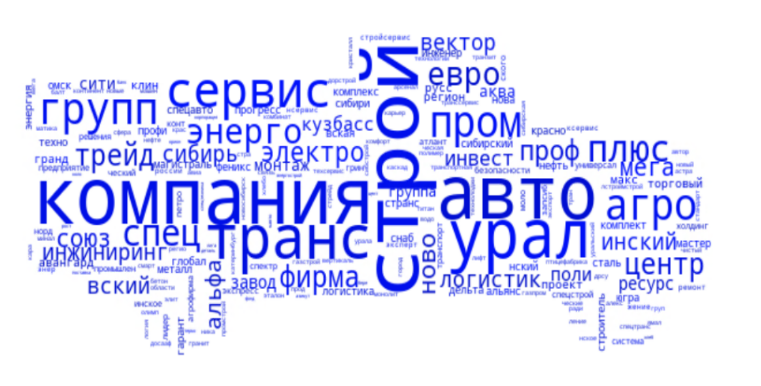

**Итого по разделу 2**
* категориальные столбцы Org, Size закодированы методом label encoder
* категориальные столбцы Company, TypeActivity удалены
* все оставшиеся числовые столбцы стандартизованы методом standard scaler

# Research

## Визуализация

In [70]:
df = pd.read_csv('data/train.csv', encoding = 'cp1251')

В данном блоке будем строить графики по исходным данным без преобразований.

### boxplot

**Ящик с усами** - график, изображающий одномерной распределение вероятностей. Такой вид диаграммы в удобной форме показывает медиану, нижний и верхний квартили, минимальное и максимальное значение выборки и выбросы (по методу IQR). Несколько таких ящиков можно нарисовать бок о бок, чтобы визуально сравнивать одно распределение с другим. Расстояния между различными частями ящика позволяют определить степень разброса (дисперсии) и асимметрии данных.

На что смотреть по boxplot?
1. Сравнить медианы по нескольким фичам
2. Сравнить IQR и усы по нескольким фичам
3. Наличие выборосов за усами
4. Смещенность распределения

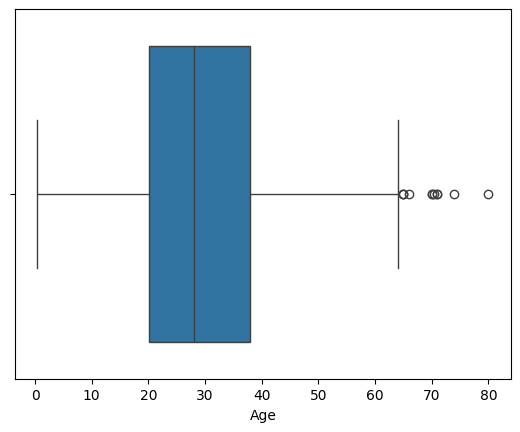

In [71]:
sns.boxplot(x='Age', data=df);

> Age - половина компаний в возрасте 20-40 лет, проверить выбросы, распределение смещено вправо

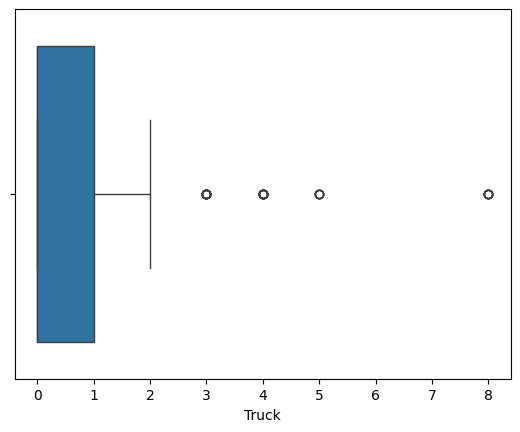

In [72]:
sns.boxplot(x='Truck', data=df);

> Truck - у половины компаний 0 или 1 грузовой автомобиль

<div class='alert alert-block alert-success'>Постройте boxplot по любой колонке</div>

<Axes: xlabel='Risk', ylabel='Age'>

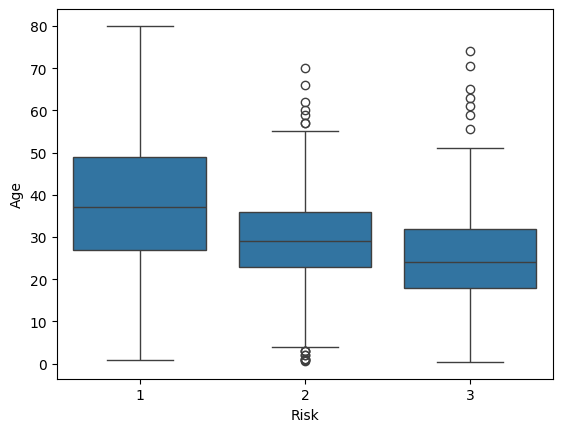

In [73]:
sns.boxplot(x='Risk', y='Age', data=df)

> С увеличением возраста понижается риск (обратная нумерация, 1-ый класс риска самый маленький)

<div class='alert alert-block alert-success'>Постройте boxplot по Org в зависимости от Risk</div>

### countplot / histplot

countplot для object колонок, histplot для numeric колонок

**Count Plot** - график, который показывает количество наблюдений в каждой категории категориальной переменной.

**Hist Plot** - Гистограмма распределения — график функции плотности распределения некоторой случайной величины, построенный по выборке в виде столбчатой диаграммы. Гистограмма группирует данные в интервалы («бины») одинаковой ширины и отображает количество наблюдений в каждом интервале.

In [74]:
df.dtypes

ClientId          int64
Target            int64
Risk              int64
Company          object
Org              object
Age             float64
Truck             int64
Car               int64
TypeActivity     object
Assets          float64
Department       object
Size             object
dtype: object

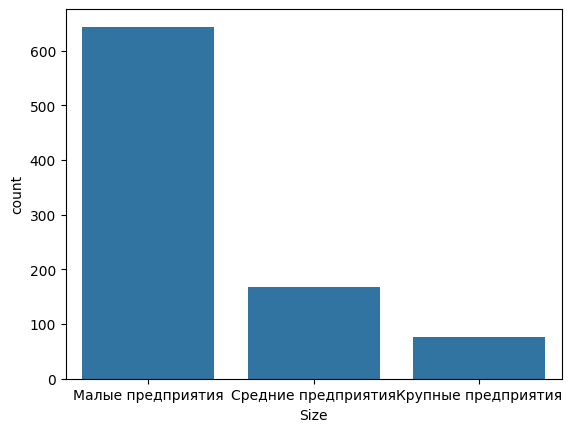

In [75]:
sns.countplot(x='Size', data=df);

> Size - большинство компаний - это малые предприятия.

In [76]:
# sns.histplot(x='Age', data=df);

> Age сильно варьируется. Распределение смещено вправо, 2 пика - около 0 лет и около 22 лет

<div class='alert alert-block alert-success'>Постройте countplot / histplot по любой колонке</div>

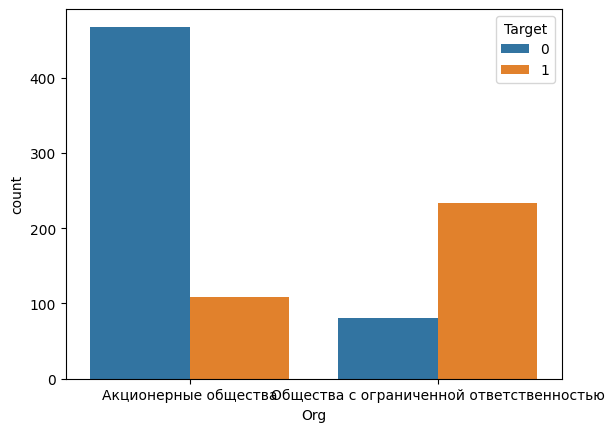

In [77]:
sns.countplot(x='Org', data=df, hue='Target');

In [78]:
# sns.histplot(data=df, 
#             x="Org", 
#             hue="Target", 
#             multiple="stack")

> Org - Target - ООО чаще являются нашими клиентами.

In [79]:
# fig, ax = plt.subplots(1, 2)
# sns.histplot(x="Age", data=df, ax=ax[0], bins=20)
# sns.boxplot(x="Age", data=df, ax=ax[1])
# plt.show()

> Как видно по двум графикам по Age нет выбросов, хотя можно было сделать такой вывод, посмотрев только на ящик с усами. По Age 2 пика, что видно по гистограмме.

### correlation matrix

Показывает попарные линейные корреляции между двумя переменными. Значения коэффициентов корреляции находятся в диапазоне от -1 до +1, при этом значение -1 указывает на сильную отрицательную корреляцию, значение +1 указывает на сильную положительную корреляцию, а значение 0 указывает на отсутствие корреляции.

Матрицу корреляций строим на стандартизованных данных.

In [80]:
df_st[numeric_columns].corr()

,Risk,Org,Age,Truck,Car,Assets,Size
Risk,1.000000,-0.131900,-0.407015,0.083081,0.018443,-0.549504,0.045702
Org,-0.131900,1.000000,-0.112851,0.114631,0.245489,0.182248,0.116569
Age,-0.407015,-0.112851,1.000000,-0.251313,-0.180705,0.118312,-0.048809
Truck,0.083081,0.114631,-0.251313,1.000000,0.414838,0.159653,-0.059961
Car,0.018443,0.245489,-0.180705,0.414838,1.000000,0.216279,-0.078665
Assets,-0.549504,0.182248,0.118312,0.159653,0.216279,1.000000,0.062141
Size,0.045702,0.116569,-0.048809,-0.059961,-0.078665,0.062141,1.000000


In [ ]:
fig = plt.subplots(figsize=(6,6))
sns.heatmap(df_st.corr(), annot=True);

Отберем только значения коэффициентов корреляции по модулю больше cor_th (задан 0.5).

In [ ]:
cor_th = 0.5

In [ ]:
c = abs(df_st.corr())>cor_th
fig = plt.subplots(figsize=(6,6))
sns.heatmap(c, vmin=-1, vmax=1, linewidths = 1, square = True);

> Прямая зависимость между факторами Target - Org, обратная зависимость между факторами Assets - Risk

<div class='alert alert-block alert-success'>Попробуйте поменять пограничное значение cor_th и построить матрицу корреляций по этому значению</div>

<div class='alert alert-block alert-success'>Посмотрите в документации pandas, какой коэф. кор. рассчитывается по умолчанию в методе corr()</div>

Однако тесная линейная связь - хитрая вещь. Она может быть там, где ее быть не должно (ложная корреляция). Это происходит по случайности и мы можем ненароком отбросить хороший признак. Что делать в таком случае? Обычно помогает логика и здравый смысл.

Пример ложной корреляции:

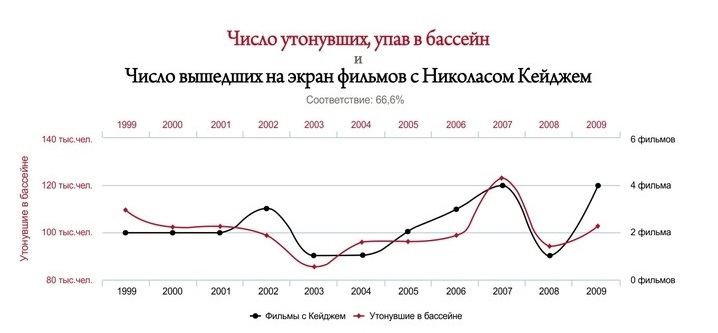

# Объединение таблиц

## concatenate with test

In [ ]:
df_part_1 = pd.read_csv('data/train.csv', encoding = 'cp1251')

In [ ]:
df_part_1.shape

In [ ]:
df_part_2 = pd.read_csv('data/test.csv', encoding = 'cp1251')

In [ ]:
df_part_2.shape

In [ ]:
list(set(df_part_1.columns) - set(df_part_2.columns))

В датафрейме df_part_2 отсутствует колонка Target

In [ ]:
df_concat = pd.concat([df_part_1, df_part_2]).reset_index(drop=True)

In [ ]:
df_concat.shape

In [ ]:
df_concat

## merge with new cols

In [ ]:
df_part_1_add = pd.read_csv('data/train_add_feat.csv', encoding = 'cp1251')

В датафрейме df_part_1_add дополнительные признаки по клиентам - AutoCnt, AutoNot

In [ ]:
sum(df_part_1_add.ClientId == df_part_1.ClientId)

In [ ]:
df_part_1.shape

In [ ]:
df_expand = df_part_1.join(df_part_1_add.set_index('ClientId'), on='ClientId', how='left')

In [ ]:
df_expand.shape

In [ ]:
df_expand

<div class='alert alert-block alert-success'>Попробуйте объединить таблицы методом merge (для этого устанавливать index не нужно)</div>